In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
import corner
from lmfit import minimize, Parameters
from astropy.io import fits
from uncertainties import ufloat
import uncertainties.unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
linmixPath = '/home/benjamin/Documents/linmix/'
os.sys.path.append(magePath)
os.sys.path.append(linmixPath)
import linmix

from magE.plotutils import * 
from magE.constutils import *

In [2]:
print('Metals at median M for z = 0:', -1.492 + 1.847 * (8.07) - 0.08026*(8.07**2))

Metals at median M for z = 0: 8.186365526


In [3]:
# Read MPA-JHU 

info = fits.open('/home/benjamin/Documents/MPA-JHU/galSpecInfo-dr8.fits')
lines = fits.open('/home/benjamin/Documents/MPA-JHU/galSpecLine-dr8.fits')
extra = fits.open('/home/benjamin/Documents/MPA-JHU/galSpecExtra-dr8.fits')

# Read my emission lines
lines_mes = pd.read_csv('/home/benjamin/Documents/analogs/results/em_lines_final.csv')

# Read abundances dictionary
abun_mes = pd.read_csv('/home/benjamin/Documents/analogs/results/metals/abundance_measured_final.csv')

# Read temperatures and densities
temp_mes = pd.read_csv('/home/benjamin/Documents/analogs/results/metals/temden_measured_final.csv')

In [4]:
# Measurements
oiii_mes = upy.uarray(lines_mes['[OIII]5007'].to_numpy(), lines_mes['[OIII]5007_err'].to_numpy())
nii_mes = upy.uarray(lines_mes['[NII]6584'].to_numpy(), lines_mes['[NII]6584_err'].to_numpy())
hb_mes = upy.uarray(lines_mes['Hb'].to_numpy(), lines_mes['Hb_err'].to_numpy())
ha_mes = upy.uarray(lines_mes['Ha'].to_numpy(), lines_mes['Ha_err'].to_numpy())

siia_mes = upy.uarray(lines_mes['[SII]6730'].to_numpy(), lines_mes['[SII]6730_err'].to_numpy())
siib_mes = upy.uarray(lines_mes['[SII]6716'].to_numpy(), lines_mes['[SII]6716_err'].to_numpy())
oi_mes = upy.uarray(lines_mes['[OI]6300'].to_numpy(), lines_mes['[OI]6300_err'].to_numpy())

bpt_y_mes = upy.log10(oiii_mes / hb_mes)
bpt_n2_x_mes = upy.log10(nii_mes / ha_mes)
bpt_s2_x_mes = upy.log10((siia_mes + siib_mes) / ha_mes)
bpt_o1_x_mes = upy.log10(oi_mes / ha_mes)

In [32]:
# BPT masks
mask_bpt = (extra[1].data['BPTCLASS'] == 1) + (extra[1].data['BPTCLASS'] == 3) #+ (extra[1].data['BPTCLASS'] == 4)
mask_galaxies = (info[1].data['PRIMTARGET'] == 64) & (info[1].data['RELIABLE'] == 1) & (info[1].data['SPECTROTYPE'] == 'GALAXY')
mask_lines = (lines[1].data['OIII_5007_FLUX'] > 0) & (lines[1].data['H_BETA_FLUX'] > 0) \
              & (lines[1].data['H_ALPHA_FLUX'] > 0) & (lines[1].data['NII_6584_FLUX'] > 0)

In [33]:
# BPT SDSS data
bpt_y = np.log10(lines[1].data['OIII_5007_FLUX'][mask_galaxies * mask_lines * mask_bpt] \
                 / lines[1].data['H_BETA_FLUX'][mask_galaxies * mask_lines * mask_bpt])
bpt_n2_x = np.log10(lines[1].data['NII_6584_FLUX'][mask_galaxies * mask_lines * mask_bpt] \
                    / lines[1].data['H_ALPHA_FLUX'][mask_galaxies * mask_lines * mask_bpt])

bpt_s2_x = np.log10((lines[1].data['SII_6717_FLUX'][mask_galaxies * mask_lines * mask_bpt] \
                   + lines[1].data['SII_6731_FLUX'][mask_galaxies * mask_lines * mask_bpt]) \
                   / lines[1].data['H_ALPHA_FLUX'][mask_galaxies * mask_lines * mask_bpt])
bpt_o1_x = np.log10( lines[1].data['OI_6300_FLUX'][mask_galaxies * mask_lines * mask_bpt]\
                    / lines[1].data['H_ALPHA_FLUX'][mask_galaxies * mask_lines * mask_bpt])

/tmp/ipykernel_158389/2384428502.py:7: RuntimeWarning: divide by zero encountered in log10
  bpt_s2_x = np.log10((lines[1].data['SII_6717_FLUX'][mask_galaxies * mask_lines * mask_bpt] \
/tmp/ipykernel_158389/2384428502.py:7: RuntimeWarning: invalid value encountered in log10
  bpt_s2_x = np.log10((lines[1].data['SII_6717_FLUX'][mask_galaxies * mask_lines * mask_bpt] \
/tmp/ipykernel_158389/2384428502.py:10: RuntimeWarning: divide by zero encountered in log10
  bpt_o1_x = np.log10( lines[1].data['OI_6300_FLUX'][mask_galaxies * mask_lines * mask_bpt]\
/tmp/ipykernel_158389/2384428502.py:10: RuntimeWarning: invalid value encountered in log10
  bpt_o1_x = np.log10( lines[1].data['OI_6300_FLUX'][mask_galaxies * mask_lines * mask_bpt]\


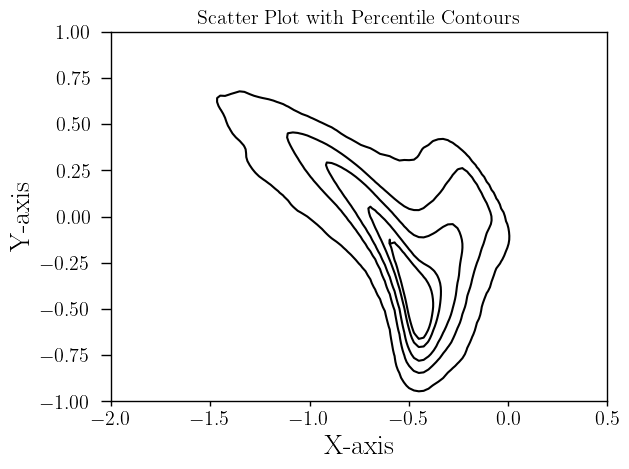

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Create scatter plot
#plt.scatter(bpt_n2_x, bpt_y, s=1, color='gray', alpha=0.2)

# Combine x and y into a single 2D array
data = np.vstack([bpt_n2_x, bpt_y])

# Perform Gaussian KDE
kde = gaussian_kde(data)

# Evaluate the density on a grid
bpt_x_grid = np.linspace(min(bpt_n2_x), max(bpt_n2_x), 100)
bpt_y_grid = np.linspace(min(bpt_y), max(bpt_y), 100)
bpt_X, bpt_Y = np.meshgrid(bpt_x_grid, bpt_y_grid)
bpt_Z = kde(np.vstack([bpt_X.ravel(), bpt_Y.ravel()])).reshape(bpt_X.shape)

# Define percentiles
percentiles = [80, 90, 95, 98, 99]

# Calculate contour levels for each percentile
levels = np.percentile(bpt_Z, percentiles)

# Add contours
contour = plt.contour(bpt_X, bpt_Y, bpt_Z, levels=levels, colors='k')


plt.xlim(-2.0, 0.5)
plt.ylim(-1.0, 1.0)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Scatter Plot with Percentile Contours')
plt.show()

In [35]:
# BPT demarcations

def kewley2001(bpt_x, mode='N2'):
    if mode == 'N2':
        den = (bpt_x - 0.47)
        bpt_y = (0.61 / den) + 1.19
        
    elif mode == 'S2':
        den = (bpt_x - 0.32)
        bpt_y = (0.72 / den) + 1.3
        
    elif mode == 'O1':
        den = (bpt_x + 0.59)
        bpt_y = (0.73 / den) + 1.33
        
    return bpt_y

def kauffmann2003(bpt_x):
    den = (bpt_x - 0.05)
    return (0.61 / den) + 1.3

In [36]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

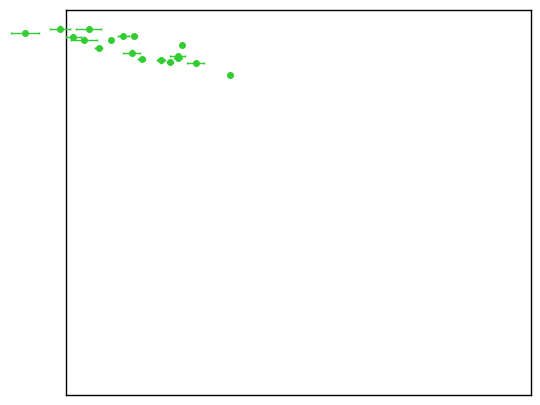

In [55]:
texPlot('on')
fig, axs = plt.subplots(1, 1, sharey=True)
fig.set_size_inches(6, 5)
fig.subplots_adjust(wspace=0)

# Plotting SDSS galaxies
#axs.scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.2)

# Local analogs
axs.errorbar(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                xerr=5*upy.std_devs(bpt_n2_x_mes), yerr=5*upy.std_devs(bpt_y_mes),
                elinewidth=1, capsize=1, fmt='o', color='limegreen', ms=4,
                label='Local analogs', zorder=5, clip_on=False)

axs.set_yticks([])
axs.set_xticks([])
axs.set_xlim(-2.0, 0.5)
axs.set_ylim(-1.0, 1.0)
#axs.xaxis.set_minor_locator(MultipleLocator(0.1))
#axs.yaxis.set_minor_locator(MultipleLocator(0.1))
axs.tick_params(direction='in', which='both')
#plt.savefig('/home/benjamin/Documents/analogs/analysis/chapter5/BPT_my_location.pdf', transparent=True)

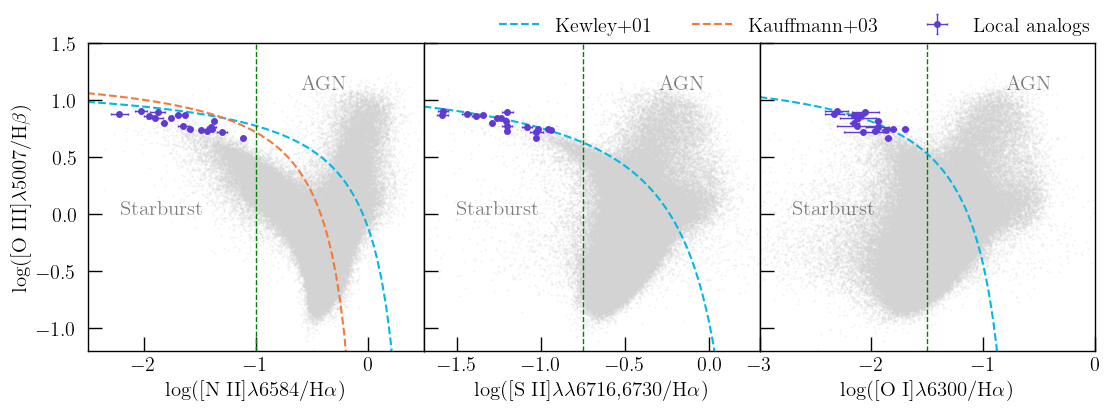

In [9]:
texPlot('on')
fig, axs = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(13, 4)
fig.subplots_adjust(wspace=0)

# Plotting SDSS galaxies
axs[0].scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.2)
axs[1].scatter(bpt_s2_x, bpt_y, s=0.5, color='lightgray', alpha=0.2)
axs[2].scatter(bpt_o1_x, bpt_y, s=0.5, color='lightgray', alpha=0.2)

# Local analogs
axs[0].errorbar(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                xerr=5*upy.std_devs(bpt_n2_x_mes), yerr=5*upy.std_devs(bpt_y_mes),
                elinewidth=1, capsize=1,
                fmt='o', color=c[2], ms=4, label='Local analogs', zorder=5)
axs[1].errorbar(upy.nominal_values(bpt_s2_x_mes), upy.nominal_values(bpt_y_mes),
                xerr=5*upy.std_devs(bpt_s2_x_mes), yerr=5*upy.std_devs(bpt_y_mes),
                elinewidth=1, capsize=1,
                fmt='o', color=c[2], ms=4, label='Local analogs', zorder=5)
axs[2].errorbar(upy.nominal_values(bpt_o1_x_mes), upy.nominal_values(bpt_y_mes),
                xerr=5*upy.std_devs(bpt_o1_x_mes), yerr=5*upy.std_devs(bpt_y_mes),
                elinewidth=1, capsize=1,
                fmt='o', color=c[2], ms=4, label='Local analogs', zorder=5)

# Mean errors
#n2_x_med_err = 5*np.mean(upy.std_devs(bpt_n2_x_mes))
#y_med_err = 5*np.mean(upy.std_devs(bpt_y_mes))
#axs[0].hlines(-0.5, -2.0 - n2_x_med_err, -2.0 + n2_x_med_err, color=c[2])
#axs[0].vlines(-2.0, -0.5 - y_med_err, -0.5 + y_med_err, color=c[2])
#
#s2_x_med_err = 5*np.mean(upy.std_devs(bpt_s2_x_mes))
#y_med_err = 5*np.mean(upy.std_devs(bpt_y_mes))
#axs[1].hlines(-0.5, -1.4 - s2_x_med_err, -1.4 + s2_x_med_err, color=c[2])
#axs[1].vlines(-1.4, -0.5 - y_med_err, -0.5 + y_med_err, color=c[2])
#
#o1_x_med_err = 5*np.mean(upy.std_devs(bpt_o1_x_mes))
#y_med_err = 5*np.mean(upy.std_devs(bpt_y_mes))
#axs[2].hlines(-0.5, -2.5 - o1_x_med_err, -2.5 + o1_x_med_err, color=c[2])
#axs[2].vlines(-2.5, -0.5 - y_med_err, -0.5 + y_med_err, color=c[2])

# Demarcations
ha_nii = np.linspace(-3.5, 0.4, 100)
ha_nii_alt = np.linspace(-3.5, 0, 100)
ha_sii = np.linspace(-1.7, 0.3, 100)
ha_oi = np.linspace(-3, -0.7, 100)
axs[0].plot(ha_nii, kewley2001(ha_nii, 'N2'), ls='--', color=c[0], label='Kewley+01')
axs[0].plot(ha_nii_alt, kauffmann2003(ha_nii_alt), ls='--', color=cz[0], label='Kauffmann+03')
axs[1].plot(ha_sii, kewley2001(ha_sii, 'S2'), ls='--', color=c[0], label='Kewley+01')
axs[2].plot(ha_oi, kewley2001(ha_oi, 'O1'), ls='--', color=c[0], label='Kewley+01')

# Labels
axs[0].set_ylabel(r'log([O III]$\lambda$5007/H$\beta$)', fontsize=15)
axs[0].set_xlabel(r'log([N II]$\lambda$6584/H$\alpha$)', fontsize=15)

axs[1].set_xlabel(r'log([S II]$\lambda\lambda$6716,6730/H$\alpha$)', fontsize=15)
axs[2].set_xlabel(r'log([O I]$\lambda$6300/H$\alpha$)', fontsize=15)

# Limits
axs[0].set_xlim(-2.5, 0.5)
axs[0].set_ylim(-1.2, 1.5)
axs[1].set_xlim(-1.7, 0.3)
axs[2].set_xlim(-3, 0)

# Legends
axs[0].legend(ncols=3, loc = (1.2, 1.0))

# Regions
axs[0].text(-0.6, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[0].text(-2.2, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[1].text(-0.3, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[1].text(-1.5, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[2].text(-0.8, 1.1, 'AGN', fontsize=15, alpha=0.5)
axs[2].text(-2.7, 0., 'Starburst', fontsize=15, alpha=0.5)

axs[0].tick_params(axis='both', direction='in', length=10)
axs[1].tick_params(axis='both', direction='in', length=10)
axs[2].tick_params(axis='both', direction='in', length=10)

axs[0].axvline(-1.0, color='green', ls='--', lw=1)
axs[1].axvline(-0.75, color='green', ls='--', lw=1)
axs[2].axvline(-1.5, color='green', ls='--', lw=1)
#fig.savefig(magePath+'analysis/chapter5/bpt_diagnosis.jpg', bbox_inches='tight', dpi=300)

In [13]:
# I found out where the equation of the local sequence comes from
# It comes from Kewley 2013.
def local_sequence(ha_nii):
    den = ha_nii + 0.08
    return 1.10 + (0.61 / den)

# This is the derived Steidel sequence.
def steidel_sequence(ha_nii):
    den = ha_nii - 0.33
    return 1.13 + (0.67 / den)

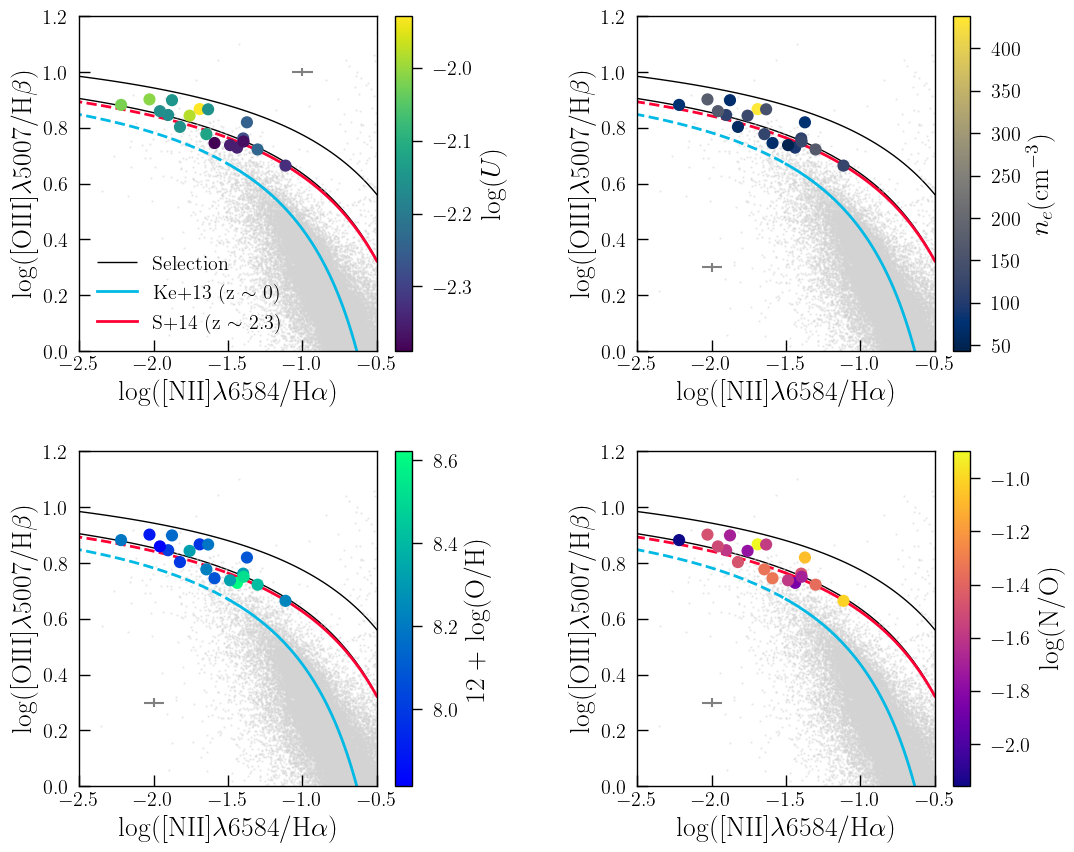

In [26]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((12, 10))
fig.subplots_adjust(wspace=0.5, hspace=0.3)

# ============================================================================
# Ionization parameter
# ============================================================================

axs[0, 0].scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.4)
ion_par = axs[0, 0].scatter(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                marker='o', c=abun_mes['log_U'], s=60, cmap='viridis', zorder=5)

plt.colorbar(ion_par, label=r'log($U$)')

ha_nii_selection = np.linspace(-3.5, -0.5, 100)
lim_sup = (0.61 / (ha_nii_selection - 0.47)) + 1.19
lim_inf = (0.66 / (ha_nii_selection - 0.31)) + 1.14
axs[0, 0].plot(ha_nii_selection, lim_inf, color='black', lw=1, zorder=0)
axs[0, 0].plot(ha_nii_selection, lim_sup, color='black', lw=1, zorder=0)
axs[0, 0].vlines(-0.5, lim_inf[-1], lim_sup[-1], lw=1, zorder=0, label='Selection')

ha_nii_literature = np.linspace(-1.5, -0.5, 100)
ha_nii_lit_ext = np.linspace(-3.5, -1.5, 100)

axs[0, 0].plot(ha_nii_literature, local_sequence(ha_nii_literature), color=c[0], lw=2,   label=r'Ke+13 (z $\sim$ 0)')
axs[0, 0].plot(ha_nii_literature, steidel_sequence(ha_nii_literature), color=c[1], lw=2, label=r'S+14 (z $\sim$ 2.3)')

axs[0, 0].plot(ha_nii_lit_ext, local_sequence(ha_nii_lit_ext), color=c[0], lw=2, ls='--')
axs[0, 0].plot(ha_nii_lit_ext, steidel_sequence(ha_nii_lit_ext), color=c[1], lw=2, ls='--')

axs[0, 0].set_ylabel(r'log([OIII]$\lambda$5007/H$\beta$)')
axs[0, 0].set_xlabel(r'log([NII]$\lambda$6584/H$\alpha$)')
axs[0, 0].set_xlim(-2.5, -0.5)
axs[0, 0].set_ylim(0, 1.2)
axs[0, 0].legend(frameon=False, loc='lower left', edgecolor='black',
           fancybox=False, framealpha=1.0);

# ============================================================================
# Electron density
# ============================================================================

axs[0, 1].scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.4)
el_den = axs[0, 1].scatter(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                marker='o', c=temp_mes['ne'], s=60, cmap='cividis', zorder=5)

plt.colorbar(el_den, label=r'$n_{e}$(cm$^{-3}$)')

ha_nii_selection = np.linspace(-3.5, -0.5, 100)
lim_sup = (0.61 / (ha_nii_selection - 0.47)) + 1.19
lim_inf = (0.66 / (ha_nii_selection - 0.31)) + 1.14
axs[0, 1].plot(ha_nii_selection, lim_inf, color='black', lw=1, zorder=0)
axs[0, 1].plot(ha_nii_selection, lim_sup, color='black', lw=1, zorder=0)
axs[0, 1].vlines(-0.5, lim_inf[-1], lim_sup[-1], lw=1, zorder=0, label='Selection')

ha_nii_literature = np.linspace(-1.5, -0.5, 100)
ha_nii_lit_ext = np.linspace(-3.5, -1.5, 100)

axs[0, 1].plot(ha_nii_literature, local_sequence(ha_nii_literature), color=c[0], lw=2,   label=r'Ke+13 (z $\sim$ 0)')
axs[0, 1].plot(ha_nii_literature, steidel_sequence(ha_nii_literature), color=c[1], lw=2, label=r'S+14 (z $\sim$ 2.3)')

axs[0, 1].plot(ha_nii_lit_ext, local_sequence(ha_nii_lit_ext), color=c[0], lw=2, ls='--')
axs[0, 1].plot(ha_nii_lit_ext, steidel_sequence(ha_nii_lit_ext), color=c[1], lw=2, ls='--')

axs[0, 1].set_ylabel(r'log([OIII]$\lambda$5007/H$\beta$)')
axs[0, 1].set_xlabel(r'log([NII]$\lambda$6584/H$\alpha$)')
axs[0, 1].set_xlim(-2.5, -0.5)
axs[0, 1].set_ylim(0, 1.2)

# ============================================================================
# Metallicity
# ============================================================================

axs[1, 0].scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.4)
metalicity = axs[1, 0].scatter(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                marker='o', c=abun_mes['log_OH'], s=60, cmap='winter', zorder=5)

plt.colorbar(metalicity, label=r'12 + log(O/H)')

ha_nii_selection = np.linspace(-3.5, -0.5, 100)
lim_sup = (0.61 / (ha_nii_selection - 0.47)) + 1.19
lim_inf = (0.66 / (ha_nii_selection - 0.31)) + 1.14
axs[1, 0].plot(ha_nii_selection, lim_inf, color='black', lw=1, zorder=0)
axs[1, 0].plot(ha_nii_selection, lim_sup, color='black', lw=1, zorder=0)
axs[1, 0].vlines(-0.5, lim_inf[-1], lim_sup[-1], lw=1, zorder=0, label='Selection')

ha_nii_literature = np.linspace(-1.5, -0.5, 100)
ha_nii_lit_ext = np.linspace(-3.5, -1.5, 100)

axs[1, 0].plot(ha_nii_literature, local_sequence(ha_nii_literature), color=c[0], lw=2,   label=r'Ke+13 (z $\sim$ 0)')
axs[1, 0].plot(ha_nii_literature, steidel_sequence(ha_nii_literature), color=c[1], lw=2, label=r'S+14 (z $\sim$ 2.3)')

axs[1, 0].plot(ha_nii_lit_ext, local_sequence(ha_nii_lit_ext), color=c[0], lw=2, ls='--')
axs[1, 0].plot(ha_nii_lit_ext, steidel_sequence(ha_nii_lit_ext), color=c[1], lw=2, ls='--')

axs[1, 0].set_ylabel(r'log([OIII]$\lambda$5007/H$\beta$)')
axs[1, 0].set_xlabel(r'log([NII]$\lambda$6584/H$\alpha$)')
axs[1, 0].set_xlim(-2.5, -0.5)
axs[1, 0].set_ylim(0, 1.2)

# ============================================================================
# Metallicity
# ============================================================================

axs[1, 1].scatter(bpt_n2_x, bpt_y, s=0.5, color='lightgray', alpha=0.4)
nitrogen = axs[1, 1].scatter(upy.nominal_values(bpt_n2_x_mes), upy.nominal_values(bpt_y_mes),
                marker='o', c=abun_mes['log_NO'], s=60, cmap='plasma', zorder=5)

plt.colorbar(nitrogen, label=r'log(N/O)')

ha_nii_selection = np.linspace(-3.5, -0.5, 100)
lim_sup = (0.61 / (ha_nii_selection - 0.47)) + 1.19
lim_inf = (0.66 / (ha_nii_selection - 0.31)) + 1.14
axs[1, 1].plot(ha_nii_selection, lim_inf, color='black', lw=1, zorder=0)
axs[1, 1].plot(ha_nii_selection, lim_sup, color='black', lw=1, zorder=0)
axs[1, 1].vlines(-0.5, lim_inf[-1], lim_sup[-1], lw=1, zorder=0, label='Selection')

ha_nii_literature = np.linspace(-1.5, -0.5, 100)
ha_nii_lit_ext = np.linspace(-3.5, -1.5, 100)

axs[1, 1].plot(ha_nii_literature, local_sequence(ha_nii_literature), color=c[0], lw=2,   label=r'Ke+13 (z $\sim$ 0)')
axs[1, 1].plot(ha_nii_literature, steidel_sequence(ha_nii_literature), color=c[1], lw=2, label=r'S+14 (z $\sim$ 2.3)')

axs[1, 1].plot(ha_nii_lit_ext, local_sequence(ha_nii_lit_ext), color=c[0], lw=2, ls='--')
axs[1, 1].plot(ha_nii_lit_ext, steidel_sequence(ha_nii_lit_ext), color=c[1], lw=2, ls='--')

axs[1, 1].set_ylabel(r'log([OIII]$\lambda$5007/H$\beta$)')
axs[1, 1].set_xlabel(r'log([NII]$\lambda$6584/H$\alpha$)')
axs[1, 1].set_xlim(-2.5, -0.5)
axs[1, 1].set_ylim(0, 1.2)

# ============================================================================
# Settings & Save
# ============================================================================

axs[0, 0].tick_params(axis='both', direction='in', length=8)
axs[0, 1].tick_params(axis='both', direction='in', length=8)
axs[1, 0].tick_params(axis='both', direction='in', length=8)
axs[1, 1].tick_params(axis='both', direction='in', length=8)

axs[0, 0].tick_params(axis='both', direction='in', length=8)
axs[0, 1].tick_params(axis='both', direction='in', length=8)
axs[1, 0].tick_params(axis='both', direction='in', length=8)
axs[1, 1].tick_params(axis='both', direction='in', length=8)

# Mean errors
n2_x_med_err = 10*np.mean(upy.std_devs(bpt_n2_x_mes))
y_med_err = 10*np.mean(upy.std_devs(bpt_y_mes))

axs[0, 0].hlines(1.0, -1.0 - n2_x_med_err, -1.0 + n2_x_med_err, color='gray')
axs[0, 0].vlines(-1.0, 1.0 - y_med_err, 1.0 + y_med_err, color='gray')

axs[0, 1].hlines(0.3, -2.0 - n2_x_med_err, -2.0 + n2_x_med_err, color='gray')
axs[0, 1].vlines(-2.0, 0.3 - y_med_err, 0.3 + y_med_err, color='gray')

axs[1, 0].hlines(0.3, -2.0 - n2_x_med_err, -2.0 + n2_x_med_err, color='gray')
axs[1, 0].vlines(-2.0, 0.3 - y_med_err, 0.3 + y_med_err, color='gray')

axs[1, 1].hlines(0.3, -2.0 - n2_x_med_err, -2.0 + n2_x_med_err, color='gray')
axs[1, 1].vlines(-2.0, 0.3 - y_med_err, 0.3 + y_med_err, color='gray')

#fig.savefig(magePath+'analysis/chapter5/bpt_n2_sequence.jpg', bbox_inches='tight', dpi=300)

In [17]:
plt.close()

# N/O ratio

In [18]:
abun_mes = pd.read_csv('/home/benjamin/Documents/analogs/results/metals/abundance_measured_final.csv')

# SDSS local galaxies 
izotov = fits.open(magePath+'analysis/Izotov_2006.fits')[1].data

# Local HII regions Berg
berg1 = fits.open(magePath+'analysis/tableB1.fits')[1].data
berg2 = fits.open(magePath+'analysis/tableB2.fits')[1].data
berg3 = fits.open(magePath+'analysis/tableB3.fits')[1].data

In [19]:
fits.open(magePath+'analysis/tableB1.fits')[1].data['e_log(O/H)']

array([0.04, 0.04, 0.02, 0.08, 0.04, 0.05, 0.03, 0.09, 0.14, 0.01, 0.13,
       0.03, 0.01, 0.04, 0.03, 0.06, 0.02, 0.11, 0.02, 0.05, 0.07, 0.09,
       0.06, 0.05, 0.03, 0.03, 0.11, 0.08, 0.03, 0.08, 0.05, 0.13, 0.1 ,
       0.01, 0.05, 0.01, 0.01, 0.07, 0.1 , 0.04, 0.06, 0.09, 0.07, 0.02,
       0.02])

In [20]:
OH_error = np.array(list(zip(abun_mes['log_OH'] - abun_mes['log_OH_16'],
                             abun_mes['log_OH_84'] - abun_mes['log_OH']))).T

NO_error = np.array(list(zip(abun_mes['log_NO'] - abun_mes['log_NO_16'],
                             abun_mes['log_NO_84'] - abun_mes['log_NO']))).T


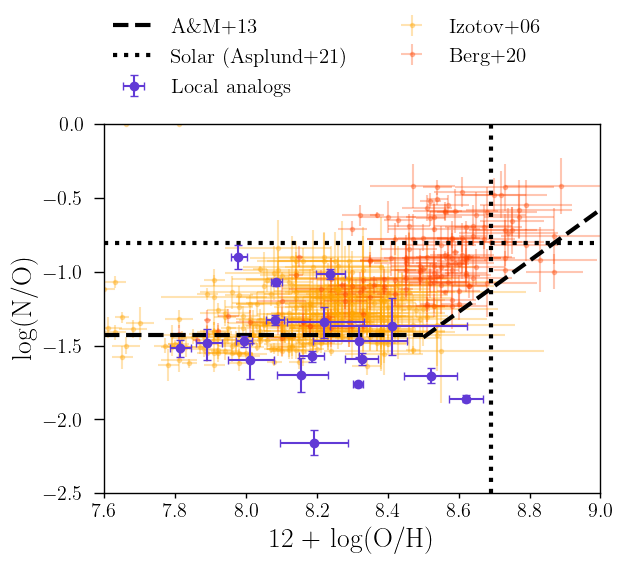

In [37]:
texPlot('on')
plt.errorbar(abun_mes['log_OH'], abun_mes['log_NO'],
            xerr=3*OH_error, yerr=3*NO_error,
            fmt='o', ls='', color=c[2],
             markersize=6, capsize=3, zorder=5, label='Local analogs')

plt.errorbar(izotov['12+logO/H'], izotov['logN/O'],
            xerr=izotov['e_12+logO/H'], yerr=izotov['e_logN/O'],
            zorder=0, alpha=0.3, ls='', fmt='.',
             color='orange', label='Izotov+06')

plt.errorbar(berg1['log(O/H)'], berg1['log(N/O)'],
            xerr=berg1['e_log(O/H)'], yerr=berg1['e_log(N/O)'],
            zorder=0, alpha=0.3, ls='', fmt='.',
             color='orangered', label='Berg+20')
plt.errorbar(berg2['log(O/H)'], berg2['log(N/O)'],
            xerr=berg2['e_log(O/H)'], yerr=berg2['e_log(N/O)'],
            zorder=0, alpha=0.3, ls='', fmt='.',
             color='orangered')
plt.errorbar(berg3['log(O/H)'], berg3['log(N/O)'],
            xerr=berg3['e_log(O/H)'], yerr=berg3['e_log(N/O)'],
            zorder=0, alpha=0.3, ls='', fmt='.',
             color='orangered')

plt.plot(np.arange(7.6, 8.5, 0.1), -1.43 * np.ones(10), ls='--', lw=3, color='black', label='A$\&$M+13')
plt.plot(np.arange(8.5, 9.1, 0.1), (1.73 * np.arange(8.5, 9.1, 0.1)) - 16.15, ls='--', lw=3, color='black')

plt.axhline(-0.809, ls=':', lw=3, label='Solar (Asplund+21)')
plt.axvline(8.69, ls=':', lw=3)

plt.xlabel('12 + log(O/H)')
plt.ylabel('log(N/O)')
plt.xlim(7.6, 9.0)
plt.ylim(-2.5, -0.0)
plt.legend(ncols=2, loc=(0.0, 1.05), fontsize=15)
plt.savefig(magePath+'analysis/chapter5/NO_ratio.pdf', bbox_inches='tight');

Text(0.7, 0.65, '$n_{e}$ = 1000 cm$^{-3}$')

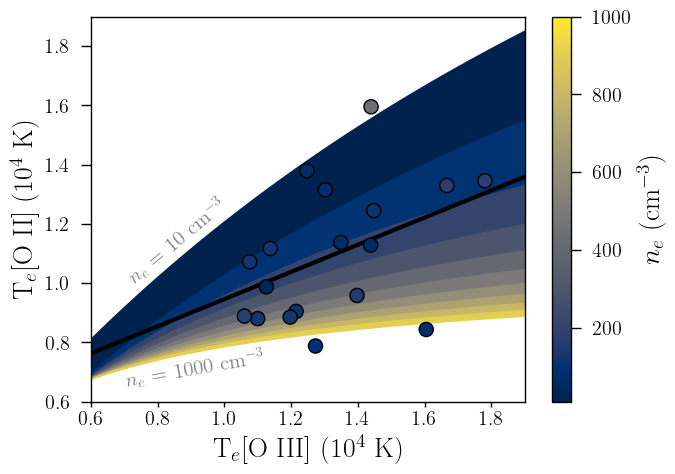

In [ ]:
import matplotlib as mpl

# Select a color map
cmap = mpl.cm.cividis
dens_to_fill = np.array([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
normalize = mpl.colors.Normalize(vmin=np.min(dens_to_fill), vmax=np.max(dens_to_fill))

texPlot('on')
fig, axs = plt.subplots(1, 1)
fig.set_size_inches((7, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs.errorbar(tm_dict['tOIII'], tm_dict['tOII'],
               #xerr=2*tOIII_error, yerr=2*tOII_error,
               marker='', markersize=12, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='white', zorder=5)
sc = axs.scatter(tm_dict['tOIII'], tm_dict['tOII'],
                 edgecolor='black',
           s=104, c=tm_dict['ne'], vmin=10., vmax=1000, zorder=10, cmap='cividis')
#axs.plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
#            ls=':', color='black')
plt.colorbar(sc, label=r'$n_{e}$ (cm$^{-3}$)')
axs.plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color='black', lw=3, label='Best-fit')


#axs.fill_between(PM17_den(0)[0], PM17_den(0)[1], PM17_den(10)[1])

for i in range(len(dens_to_fill) - 1):
    axs.fill_between(PM17_den(dens_to_fill[i])[0],
                     PM17_den(dens_to_fill[i])[1], PM17_den(dens_to_fill[i+1])[1],
                     color=cmap(normalize(dens_to_fill[i])), zorder=0)

axs.set_xlim(0.6, 1.9)
axs.set_ylim(0.6, 1.9)
axs.set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs.set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')

axs.text(0.7, 1.0, r'$n_{e}$ = 10 cm$^{-3}$', rotation=40, fontsize=15, alpha=0.5)
axs.text(0.7, 0.65, r'$n_{e}$ = 1000 cm$^{-3}$', rotation=10, fontsize=15, alpha=0.5)
#fig.savefig('./chapter5/temp_dens_dependence.pdf', bbox_inches='tight')

In [25]:
np.median(upy.uarray(abun_mes['log_OH'].values, np.mean(OH_error, axis=0)))

8.187321774374775+/-0.01708600347892795